In [21]:
import pandas as pd

url = "hygdatav3.csv"
df = pd.read_csv(url)

df = df[df['mag'] <= 6.0]

df = df.rename(columns={'proper': 'name', 'mag': 'magnitude'})

df = df.dropna(subset=['ra', 'dec'])

In [22]:
print(df['ra'].mean())

11.914163133754192


c:\Users\burak\OneDrive\Masaüstü\AstroWatch-Project-demo\.venv\Lib\site-packages\matplotlib\collections.py:1115: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
c:\Users\burak\OneDrive\Masaüstü\AstroWatch-Project-demo\.venv\Lib\site-packages\matplotlib\collections.py:1115: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


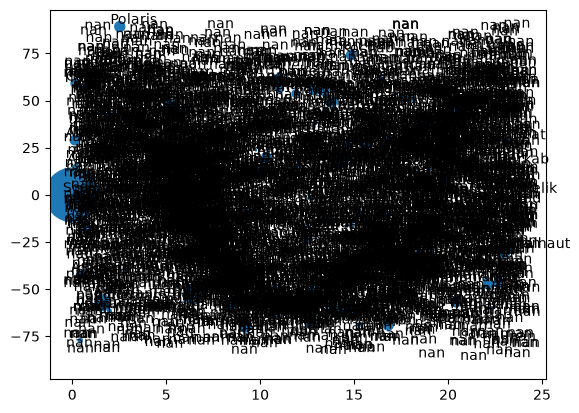

In [23]:
import matplotlib.pyplot as plt

# Boyutları formülümüzle hesapla
yildiz_boyutlari = (3.0 - df['magnitude']) * 50

# s= parametresine hesapladığımız boyutları ver (ve gece gökyüzü hissi için rengi koyu yapabiliriz ama şimdilik sadece boyuta odaklanalım)
plt.scatter(df['ra'], df['dec'], s=yildiz_boyutlari)
for index, row in df.iterrows():
    plt.text(row['ra']-0.5,row['dec']+1.4,row['name'])

plt.show()

In [24]:
from datetime import datetime 
import math
import numpy as np
now=datetime.utcnow()


def calculate_juliandate(dt):
    ut_time=dt.hour+(dt.minute/60)+(dt.second/3600)
    Y=dt.year
    M=dt.month
    D=dt.day
    JD=(367*Y)-(7*(Y+((M+9)//12))//4)+((275*M)//9)+D+1721013.5+ut_time/24
    return JD

JD=calculate_juliandate(now) 
def calculate_lst(jd,boylam): 
    T = (jd - 2451545.0) / 36525.0
    
    GMST = 6.697374558 + (2400.051336 * T) + (0.000025862 * T * T)

    ut_time = ((jd + 0.5) % 1.0) * 24.0
    GMST = GMST + (ut_time * 1.00273790935)
    
    GMST = GMST % 24
    lst = GMST + (boylam / 15)
    return lst % 24

lst=calculate_lst(JD,27.14)
print(lst)

HA=lst-df['ra']
df['name'],HA

def calculate_altitude(dec, ha, lat):
    dec=np.radians(dec)
    lat=np.radians(lat)
    ha=np.radians(ha*15)
    alt=np.sin(dec)*np.sin(lat)+np.cos(dec)*np.cos(lat)*np.cos(ha)
    alt=np.arcsin(alt)
    return np.degrees(alt)


def calculate_azimuth(dec, ha, lat):
    dec=np.radians(dec)
    lat=np.radians(lat)
    ha=np.radians(ha*15)

    x=np.cos(lat)*np.sin(dec)-np.sin(lat)*np.cos(dec)*np.cos(ha)
    y=-np.sin(ha)*np.cos(dec)

    azimuth=np.arctan2(y,x)
    azimuth=np.degrees(azimuth)
    return azimuth%360

df['altitude'] = calculate_altitude(df['dec'], HA, 38.4)
df['azimuth'] = calculate_azimuth(df['dec'], HA, 38.4)
df['ha']=lst-df['ra']
print(df[['name', 'azimuth','altitude','ha']])
    







17.772286073699398
       name     azimuth   altitude         ha
0       Sol   87.876795  -2.676256  17.772286
88      NaN  130.608789 -30.039747  17.754345
107     NaN  132.193492 -30.722492  17.750031
122     NaN  163.512094 -38.101676  17.745670
124     NaN   34.198671  31.285345  17.745337
...     ...         ...        ...        ...
119193  NaN  174.309689  43.255454  -0.278916
119196  NaN  171.889320  53.832981  -0.318704
119257  NaN  163.764543  12.309574  -1.334561
119395  NaN  107.185429  35.639880  -3.469105
119546  NaN  113.152085  -7.046177  -5.393019

[5069 rows x 4 columns]


C:\Users\burak\AppData\Local\Temp\ipykernel_12636\498243887.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now=datetime.utcnow()


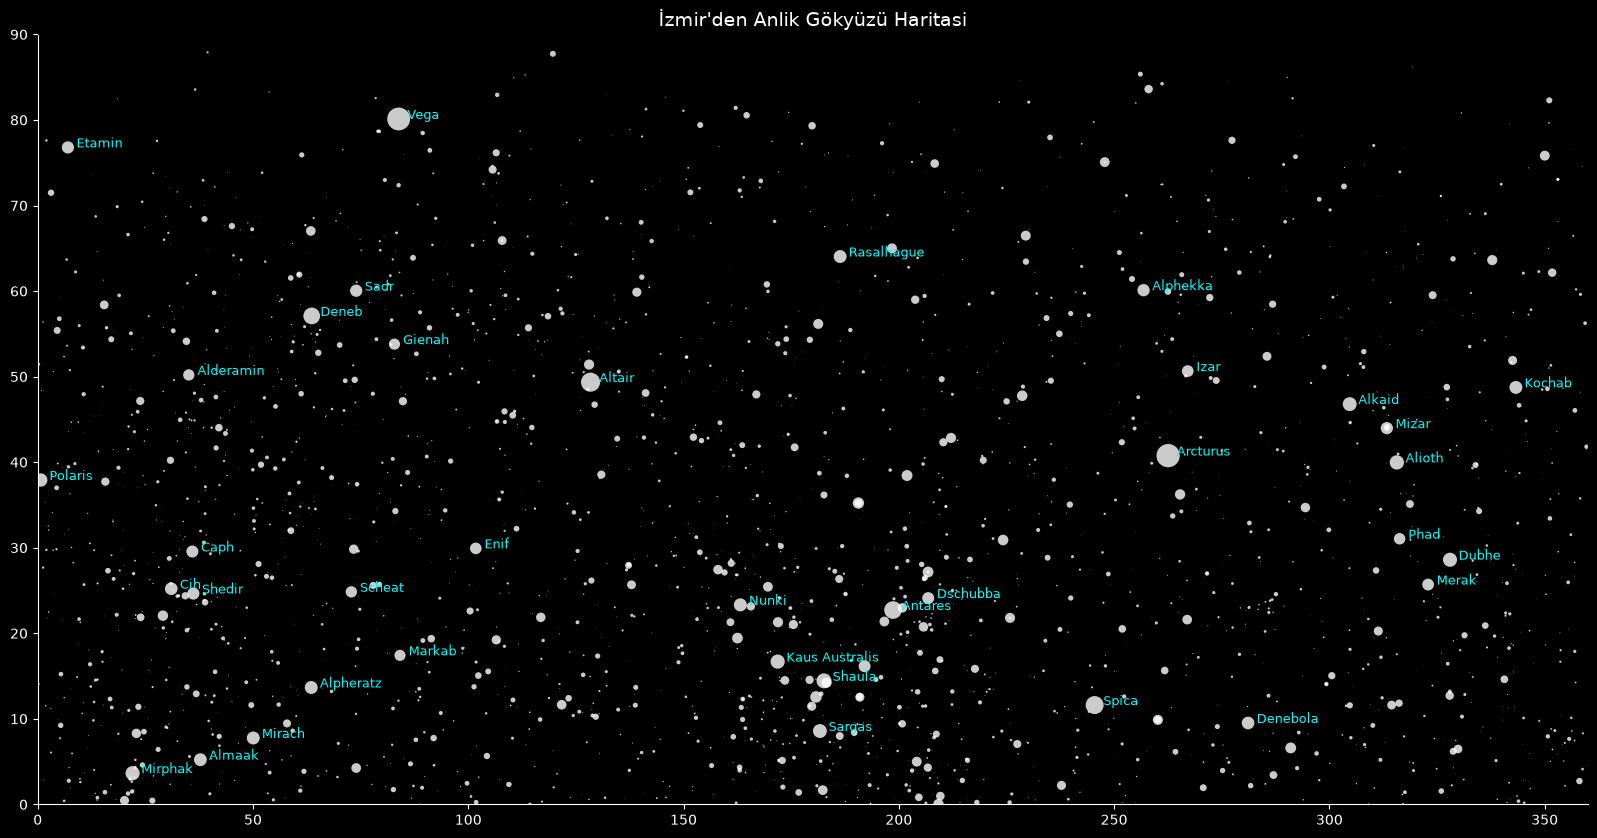

In [25]:

df_visible = df[df['altitude'] > 0]


star_sizes = (6.5 - df_visible['magnitude']) **3

plt.figure(figsize=(20, 10), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')


plt.scatter(df_visible['azimuth'], df_visible['altitude'], 
            s=star_sizes, color='white', alpha=0.8, edgecolors='none')

plt.xlim(0, 360)
plt.ylim(0, 90)


ax.tick_params(colors='white')
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')

for index, row in df_visible[df_visible['magnitude'] < 2.5].iterrows():
    if pd.notna(row['name']): # İsmi olanları yaz
        plt.text(row['azimuth'] + 2, row['altitude'], row['name'], 
                 color='cyan', fontsize=9)


plt.title("İzmir'den Anlik Gökyüzü Haritasi", color='white', fontsize=14)
plt.show()